In [23]:
from ultralytics import YOLO

model_path = "../Models/yolov8n.pt"
model = YOLO(model_path)

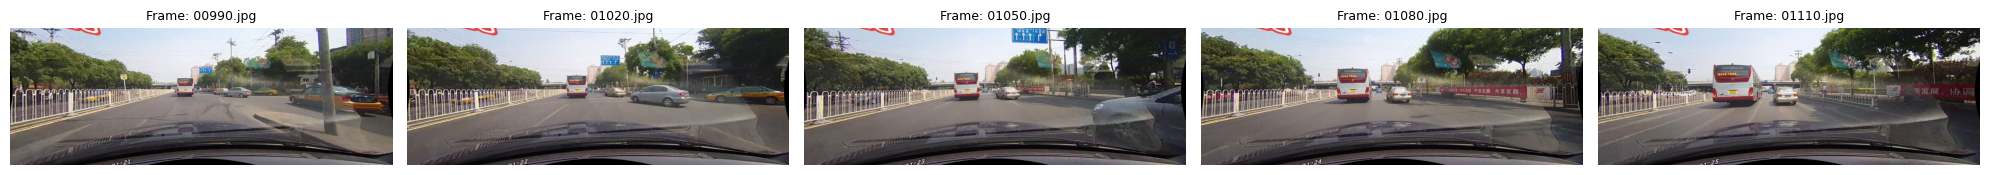

In [24]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np 
from pathlib import Path


base_dir = Path.cwd().parent
data_dir = base_dir / "Data"

train_img_path = data_dir / "driver_37_30frame"/"driver_37_30frame"/ "05191020_0411.MP4"

# 1. Get all files and sort them to maintain the time sequence
# Filtering for files that look like your numbered frames (e.g., 01710, 01740)
# We exclude the ".lines" text files to only get the JPGs
all_images = sorted([
    p for p in os.listdir(train_img_path) 
    if p.endswith(('.jpg', '.png', '.jpeg')) and ".lines" not in p
])

# 2. Select a random starting index for a continuous block of 5
if len(all_images) >= 5:
    start_idx = random.randint(0, len(all_images) - 5)
    test_images = all_images[start_idx : start_idx + 5]
else:
    test_images = all_images
    print(f"Note: Only {len(all_images)} images available.")

# Save the sequence to JSON
with open("test_images.json", "w") as f:
    json.dump(test_images, f)

# 3. Plotting the sequence
plt.figure(figsize=(20, 5))
for i, img_name in enumerate(test_images):
    img_path = os.path.join(train_img_path, img_name)
    image = Image.open(img_path)
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    # Displaying the filename so you can verify they are sequential
    plt.title(f"Frame: {img_name}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()